## **Step 1: Mount Google Drive**

In [4]:
# from google.colab import drive

# drive.mount('/content/drive')

## **Step 2: Set Dataset Path**

In [5]:
# dataset_path = "/content/drive/MyDrive/Uni Life/Junior/3rd Term/Deep Learning/Project/Dataset"

dataset_path = "/Users/leonmarco/Downloads/Dataset"

## **Step 3: Import Libraries**

In [6]:
%pip install tensorflow matplotlib

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

## **Step 4: Prepare Image Dataset**

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## **Step 5: Load Training Dataset**

In [9]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 296 images belonging to 3 classes.


## **Step 6: Load Validation Dataset**

In [10]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 74 images belonging to 3 classes.


## **Step 7: Build Simple CNN**

In [11]:
model = models.Sequential()

model.add(layers. Conv2D(32, (3,3),
                         activation="relu",
                         input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3),
                        activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))

model.add(layers.Dense(train_data.num_classes, 
                       activation="softmax"))

/opt/miniconda3/envs/ccmaclrl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Step 8: Compile Model**

In [12]:
model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 9: Train Model**

In [13]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.4459 - loss: 1.4605 - val_accuracy: 0.5946 - val_loss: 0.8892
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.7432 - loss: 0.6086 - val_accuracy: 0.6622 - val_loss: 0.6901
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8041 - loss: 0.4389 - val_accuracy: 0.6622 - val_loss: 0.6382
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8851 - loss: 0.2896 - val_accuracy: 0.6351 - val_loss: 0.7868
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9020 - loss: 0.2296 - val_accuracy: 0.6081 - val_loss: 0.6766
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.9662 - loss: 0.1507 - val_accuracy: 0.5405 - val_loss: 0.9601
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.9831 - loss: 0.0752 - val_accuracy: 0.5946 - val_loss: 1.0942
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.9865 - loss: 0.0652 - val_accuracy: 0.5946 - val_loss:

## **Step 10: Evaluate Model**

In [14]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy: ", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6216 - loss: 1.2184
Validation Accuracy:  0.6216216087341309


## **Step 11: Plot Accuracy**

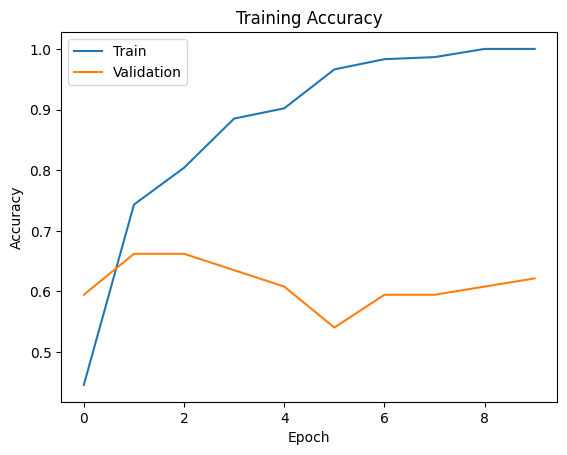

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

## **Test**

Please select an image in the popup window...
Successfully loaded: /Users/leonmarco/Downloads/Dataset/Improperly Wearing Facemask/IMG_4834.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class: Improperly Wearing Facemask


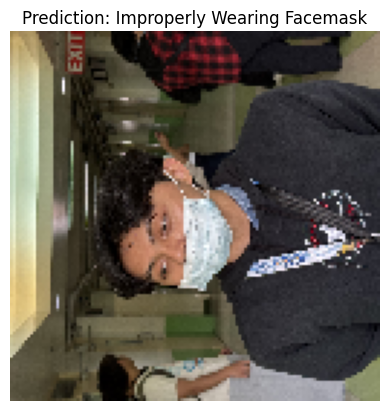

In [22]:
import tkinter as tk
from tkinter import filedialog
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a local file browser popup
root = tk.Tk()
root.withdraw() # Hides the background main window
root.call('wm', 'attributes', '.', '-topmost', True) # Forces the popup to the front

print("Please select an image in the popup window...")
# Opens the file explorer and saves the path of the file you click
filename = filedialog.askopenfilename(title="Select an image to test")

if not filename:
    print("Upload canceled. Please run the cell again to select a file.")
else:
    print(f"Successfully loaded: {filename}")
    
    # 2. Load the image and resize to the same size used in training
    img = image.load_img(filename, target_size=(128,128))
     
    # 3. Convert image to numpy array
    img_array = image.img_to_array(img)
     
    # 4. Normalize pixel values (same preprocessing used during training)
    img_array = img_array / 255.0
     
    # 5. Expand dimensions so the model receives a batch
    img_array = np.expand_dims(img_array, axis=0)
     
    # 6. Predict class
    prediction = model.predict(img_array)
     
    # 7. Get predicted class index
    predicted_class = np.argmax(prediction)
     
    # 8. Retrieve class labels from training dataset
    # (Requires train_data to be loaded in memory)
    class_labels = list(train_data.class_indices.keys())
     
    # 9. Display the image
    plt.imshow(img)
    plt.axis('off')
     
    # 10. Display predicted label
    print("Predicted Class:", class_labels[predicted_class])
    plt.title("Prediction: " + class_labels[predicted_class])
    plt.show()

# from google.colab import files
# from tensorflow.keras.preprocessing import image
# import numpy as np
# import matplotlib.pyplot as plt

# # Upload an image file
# uploaded = files.upload()
 
# # Get uploaded file name
# filename = list(uploaded.keys())[0]
 
# # Load the image and resize to the same size used in training
# img = image.load_img(filename, target_size=(128,128))
 
# # Convert image to numpy array
# img_array = image.img_to_array(img)
 
# # Normalize pixel values (same preprocessing used during training)
# img_array = img_array / 255.0
 
# # Expand dimensions so the model receives a batch
# img_array = np.expand_dims(img_array, axis=0)
 
# # Predict class
# prediction = model.predict(img_array)
 
# # Get predicted class index
# predicted_class = np.argmax(prediction)
 
# # Retrieve class labels from training dataset
# class_labels = list(train_data.class_indices.keys())
 
# # Display the image
# plt.imshow(img)
# plt.axis('off')
 
# # Display predicted label
# print("Predicted Class:", class_labels[predicted_class])
 
# # Show image with title
# plt.title("Prediction: " + class_labels[predicted_class])
# plt.show()